In [27]:
# Importiing required files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.impute import KNNImputer

**Data reading:**

In [28]:
df=pd.read_csv('/content/ManipalRains.csv')

In [29]:
#head
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,01-12-2008,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,02-12-2008,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,03-12-2008,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,04-12-2008,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,05-12-2008,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [30]:
#tail
df.tail()


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
145455,21-06-2017,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,22-06-2017,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,23-06-2017,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,24-06-2017,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No
145459,25-06-2017,Uluru,14.9,NaN,0.0,NaN,NaN,NaN,NaN,ESE,...,62.0,36.0,1020.2,1017.9,8.0,8.0,15.0,20.9,No,NaN


**Sanity check of data:**

In [31]:
#shape
df.shape

(145460, 23)

In [32]:
#info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

**Checking of missing values:**

In [33]:
#Count of missing values
missing_value=df.isnull().sum()
print(missing_value)

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64


In [34]:
# Percentage of missing values
total_cell=np.prod(df.shape)
total_missing=missing_value.sum()
percentage_missing=(total_missing/total_cell)*100
print(percentage_missing)

10.259745694319072


In [35]:
#checking duplicates
df.duplicated().sum()

np.int64(0)

In [36]:
#garbage values handling

for i in df.select_dtypes(include='object'):
  print(df[i].value_counts())
  print("\n")

Date
24-06-2017    49
23-06-2017    49
22-06-2017    49
21-06-2017    49
20-06-2017    49
              ..
27-01-2008     1
28-01-2008     1
29-01-2008     1
30-01-2008     1
31-01-2008     1
Name: count, Length: 3436, dtype: int64


Location
Canberra            3436
Sydney              3344
Adelaide            3193
Darwin              3193
Hobart              3193
Perth               3193
Melbourne           3193
Brisbane            3193
Albury              3040
MountGinini         3040
GoldCoast           3040
Wollongong          3040
MountGambier        3040
Launceston          3040
AliceSprings        3040
Albany              3040
Townsville          3040
Bendigo             3040
Cairns              3040
Ballarat            3040
Penrith             3039
Newcastle           3039
Tuggeranong         3039
PerthAirport        3009
Williamtown         3009
Cobar               3009
BadgerysCreek       3009
SydneyAirport       3009
Richmond            3009
Moree               3009
CoffsHa

**Data analysis:**

In [37]:
#all statistics parameters

#t for transpose to see all columns
print(df.describe().T)

#for object dtype
print(df.describe(include="object"))


                  count         mean        std    min     25%     50%  \
MinTemp        143975.0    12.194034   6.398495   -8.5     7.6    12.0   
MaxTemp        144199.0    23.221348   7.119049   -4.8    17.9    22.6   
Rainfall       142199.0     2.360918   8.478060    0.0     0.0     0.0   
Evaporation     82670.0     5.468232   4.193704    0.0     2.6     4.8   
Sunshine        75625.0     7.611178   3.785483    0.0     4.8     8.4   
WindGustSpeed  135197.0    40.035230  13.607062    6.0    31.0    39.0   
WindSpeed9am   143693.0    14.043426   8.915375    0.0     7.0    13.0   
WindSpeed3pm   142398.0    18.662657   8.809800    0.0    13.0    19.0   
Humidity9am    142806.0    68.880831  19.029164    0.0    57.0    70.0   
Humidity3pm    140953.0    51.539116  20.795902    0.0    37.0    52.0   
Pressure9am    130395.0  1017.649940   7.106530  980.5  1012.9  1017.6   
Pressure3pm    130432.0  1015.255889   7.037414  977.1  1010.4  1015.2   
Cloud9am        89572.0     4.447461  

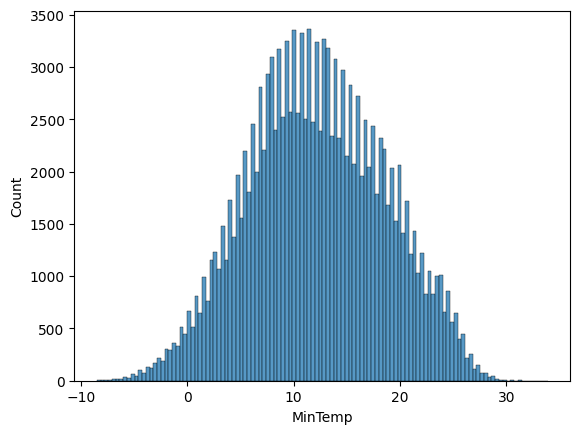

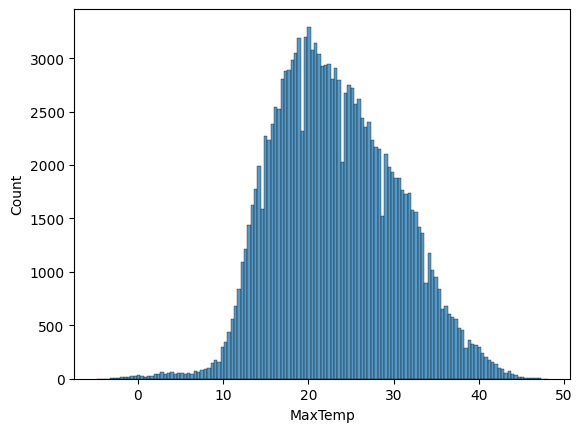

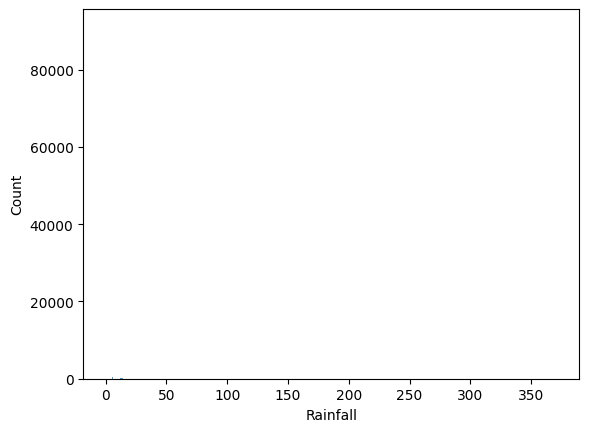

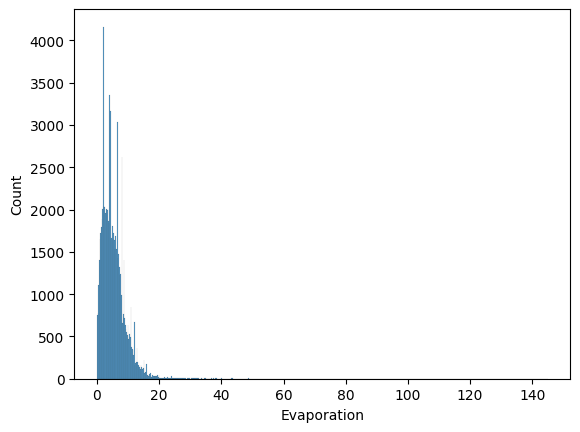

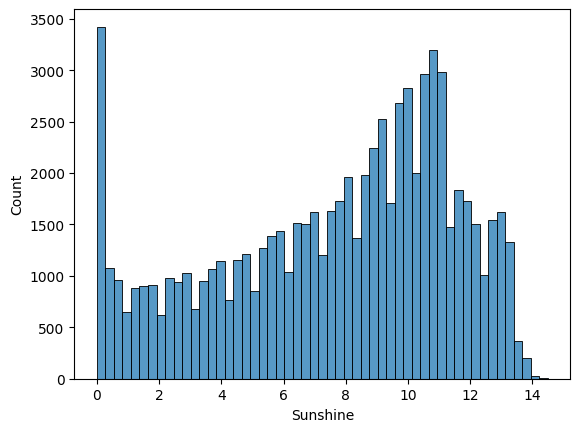

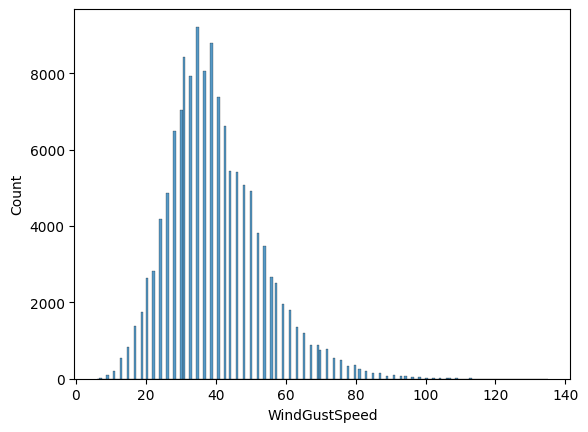

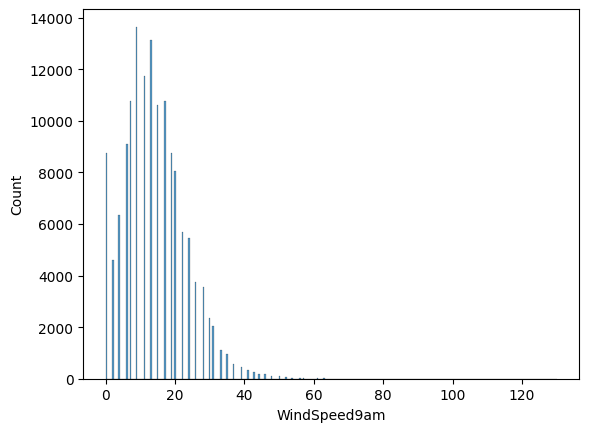

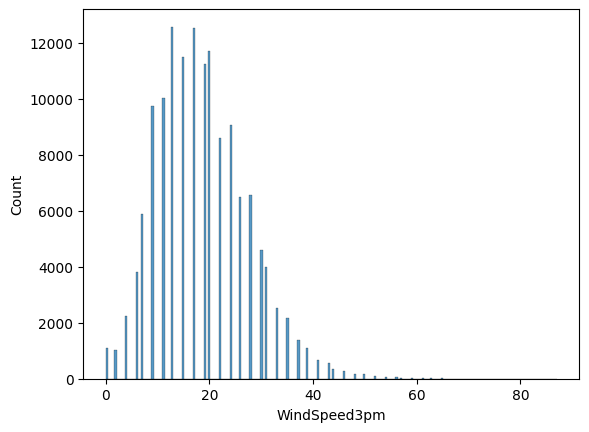

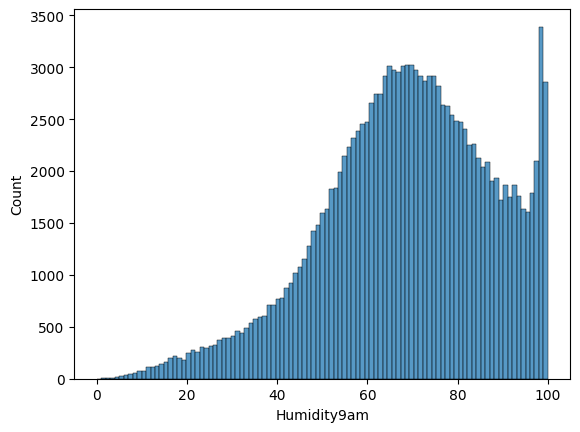

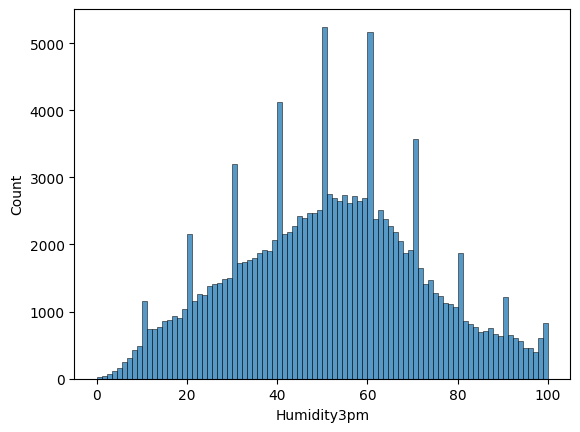

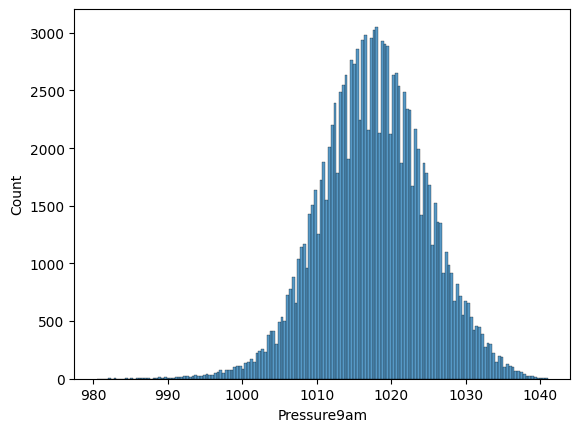

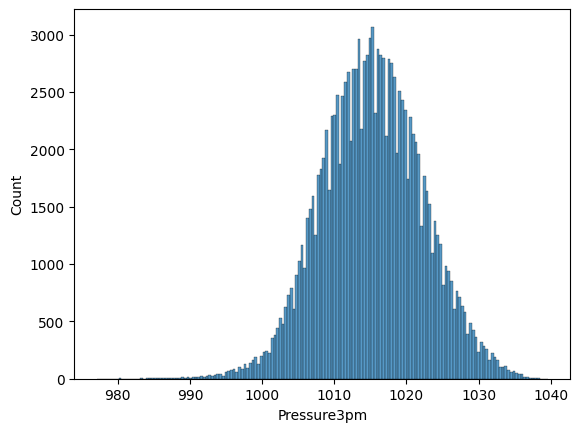

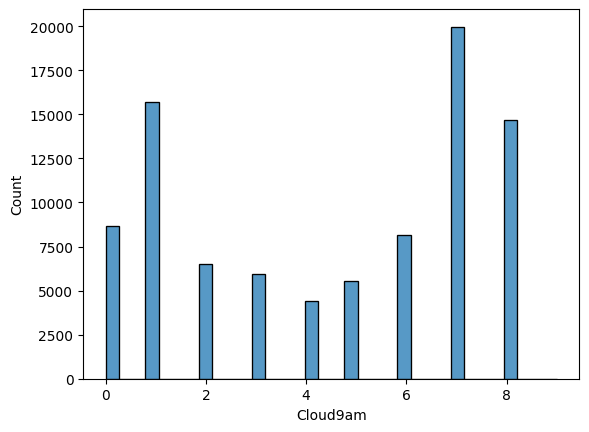

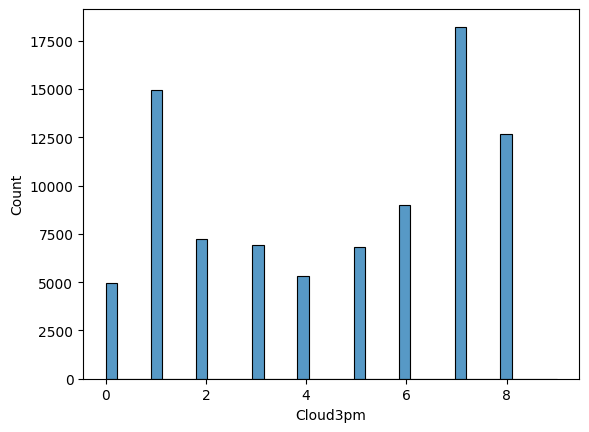

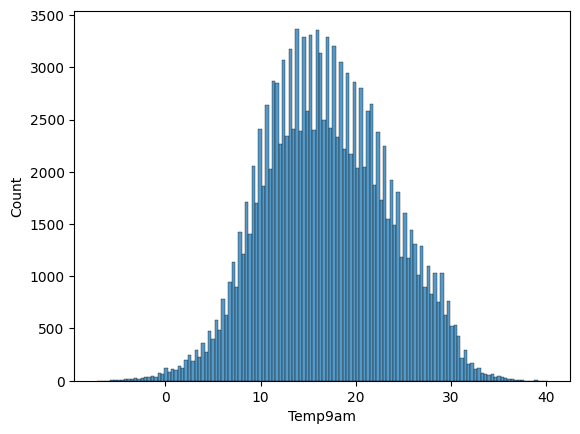

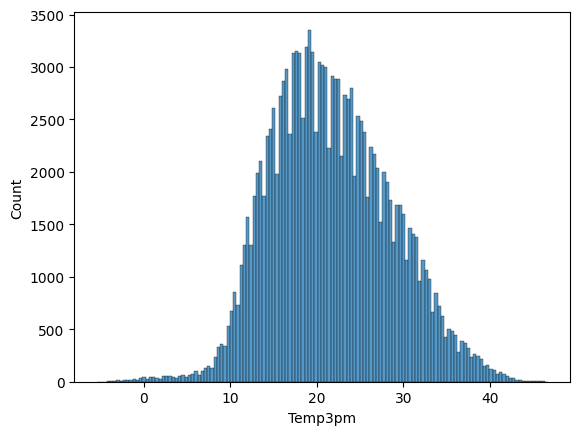

In [38]:
#histogram of data with numbers
for i in df.select_dtypes(include="number").columns:
    sb.histplot(data=df, x=i)
    plt.show()

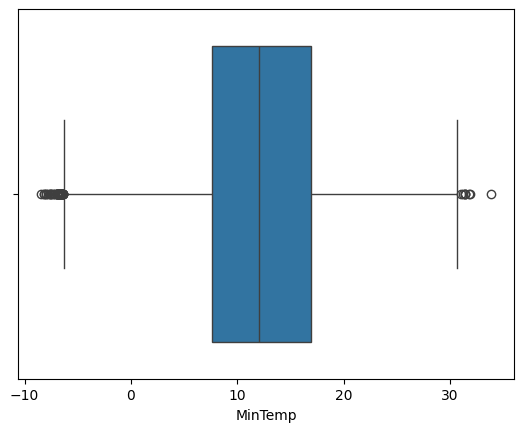

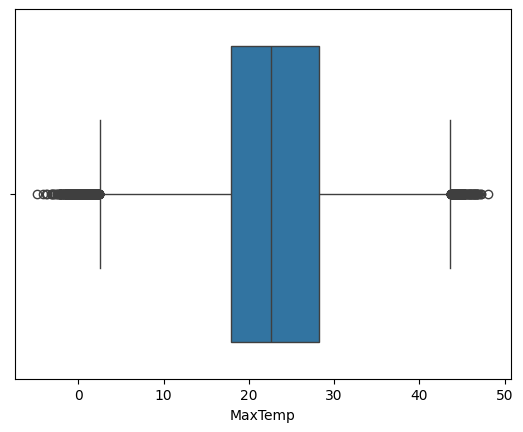

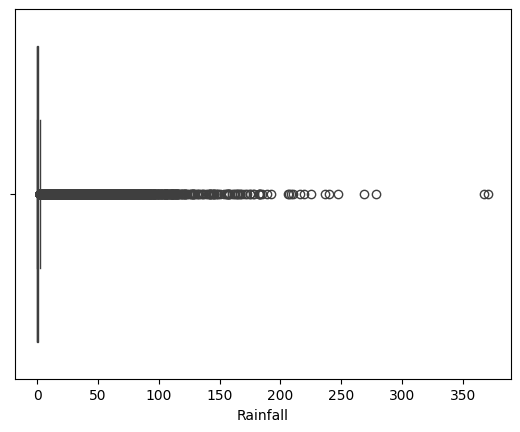

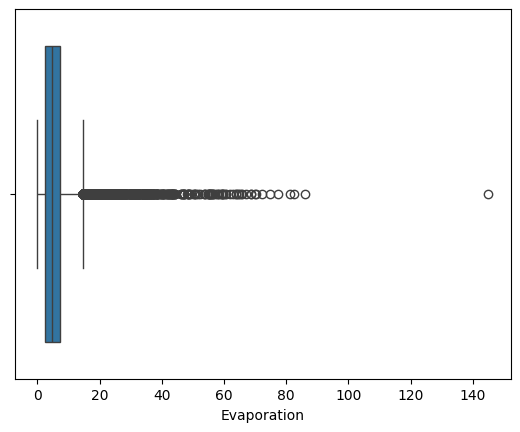

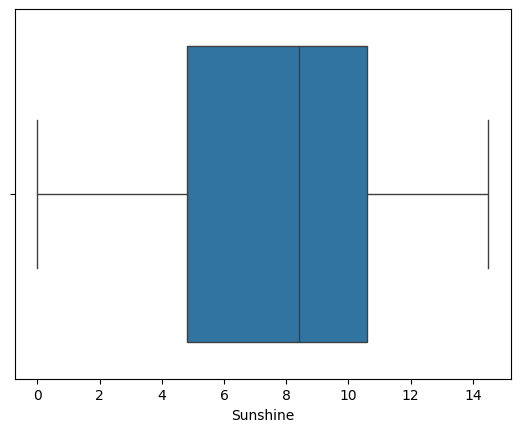

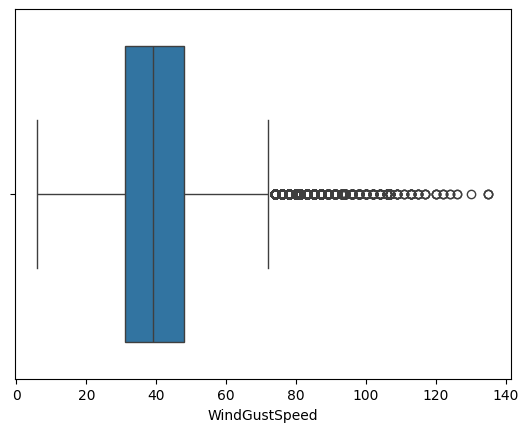

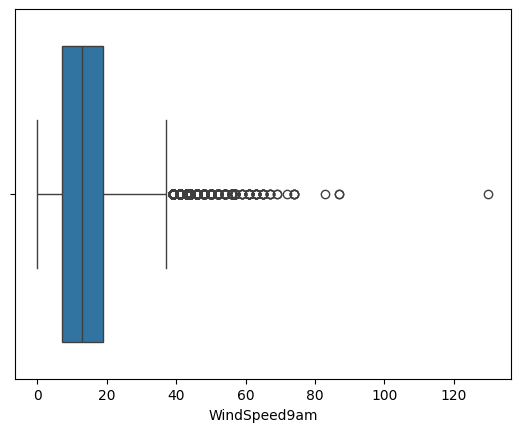

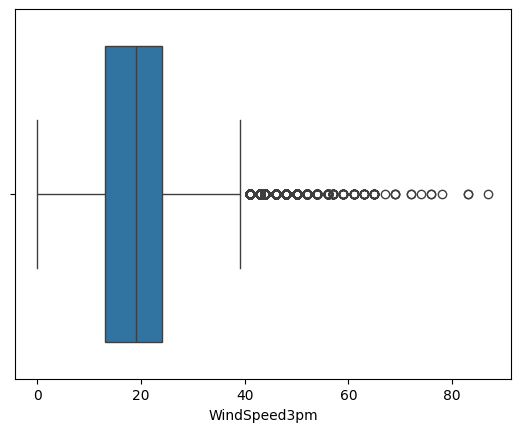

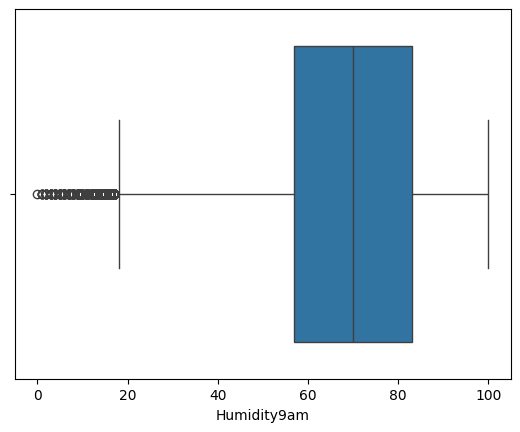

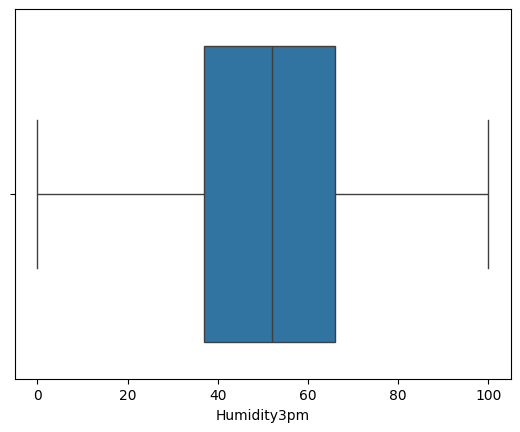

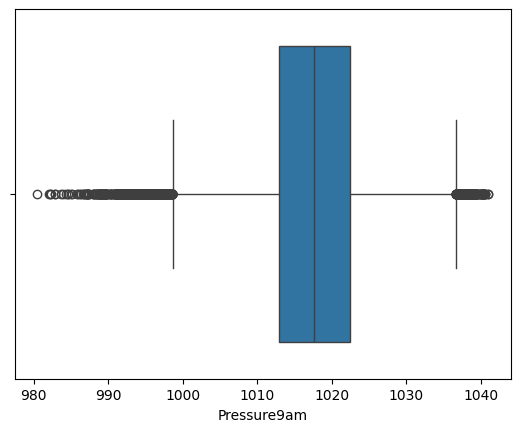

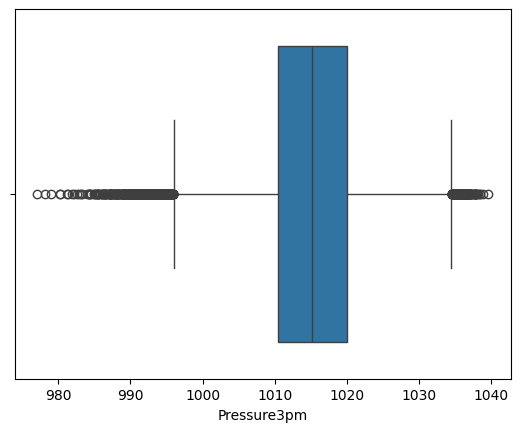

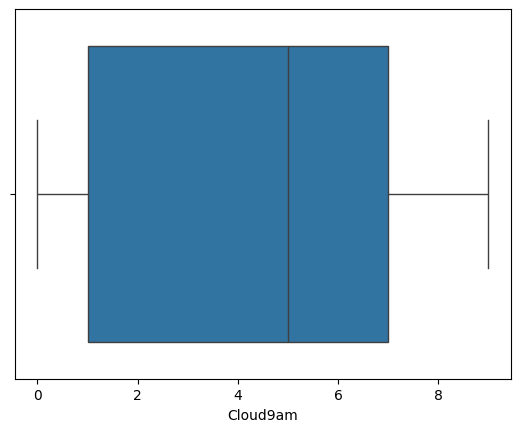

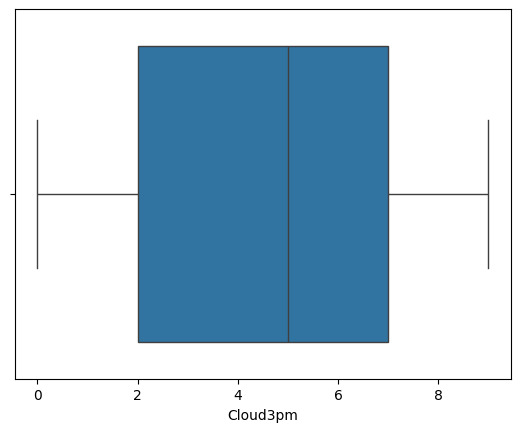

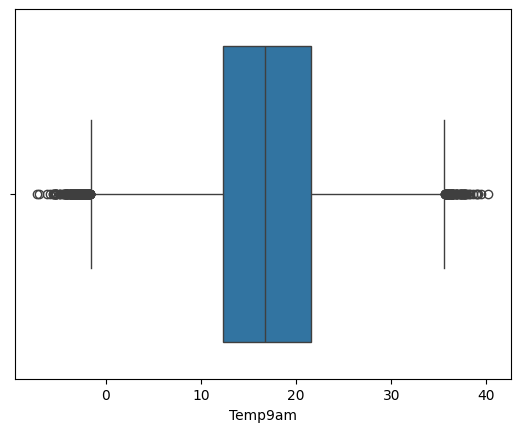

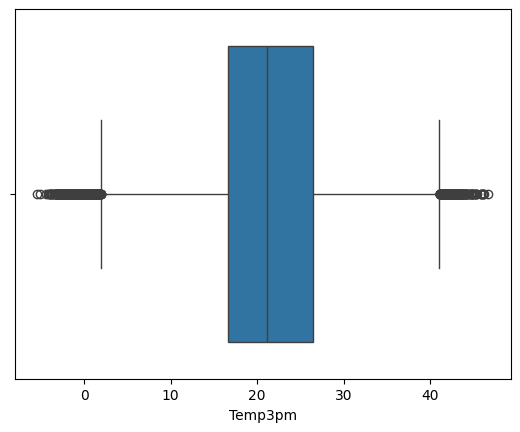

In [39]:
#boxplot to see outliers
for i in df.select_dtypes(include="number").columns:
    sb.boxplot(data=df, x=i)
    plt.show()


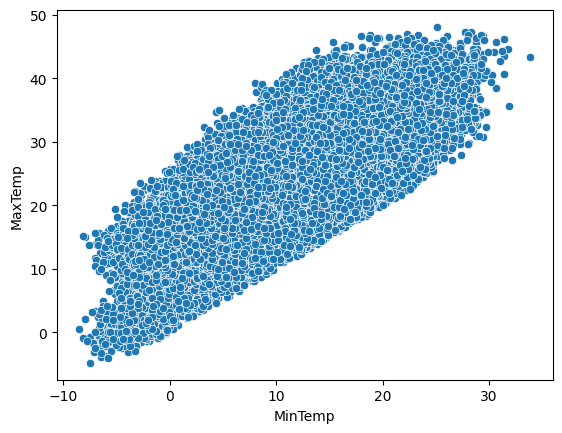

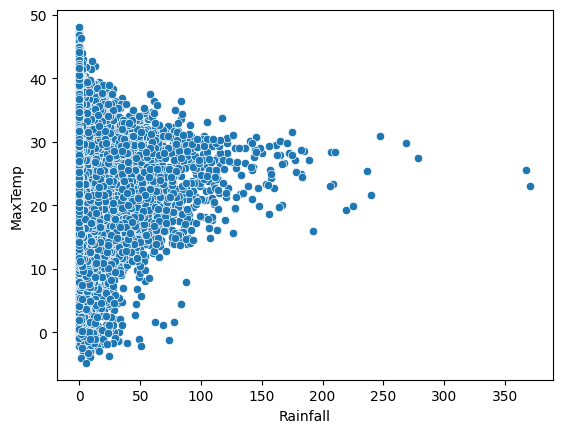

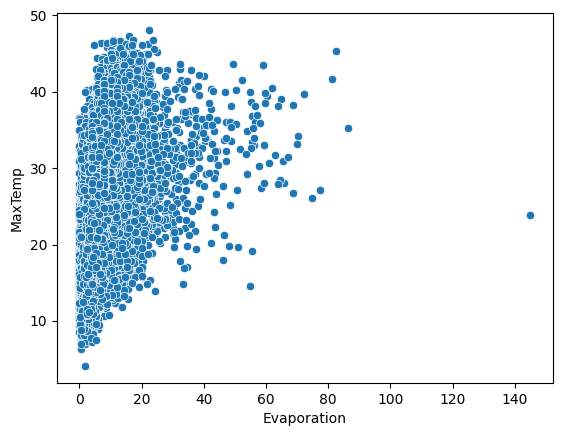

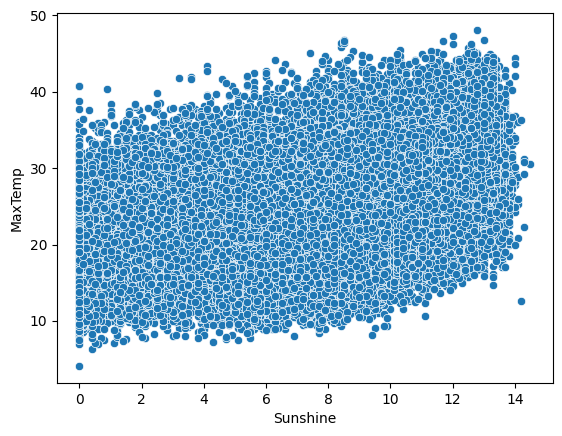

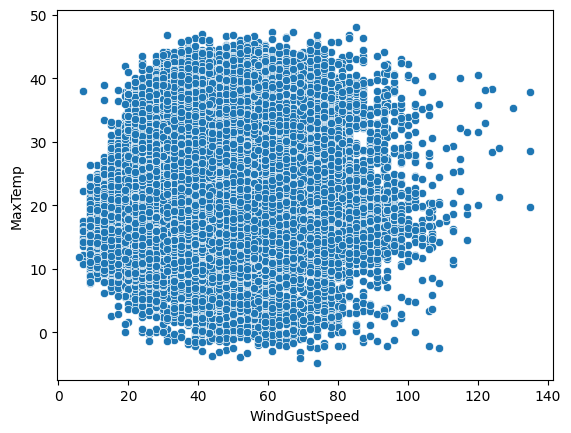

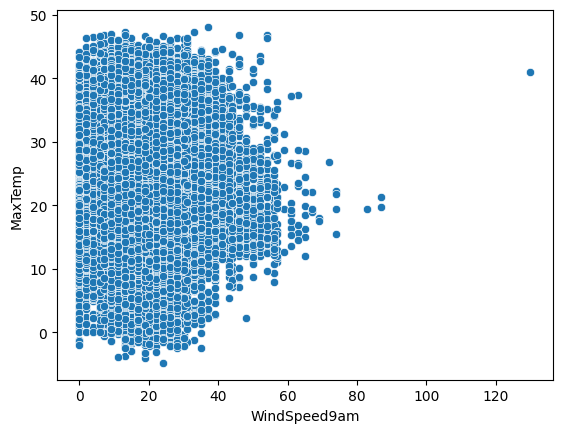

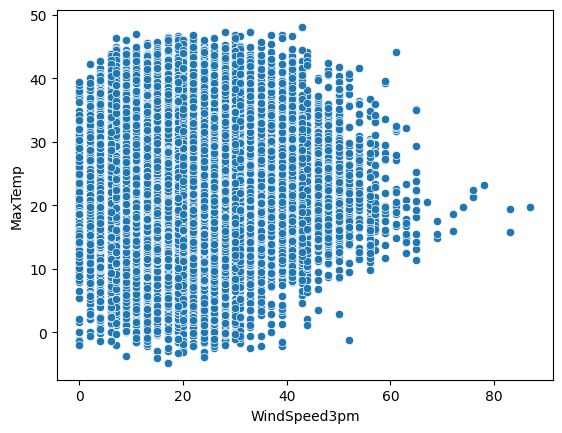

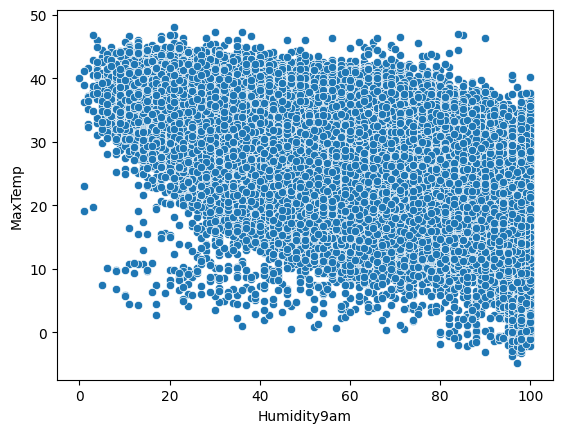

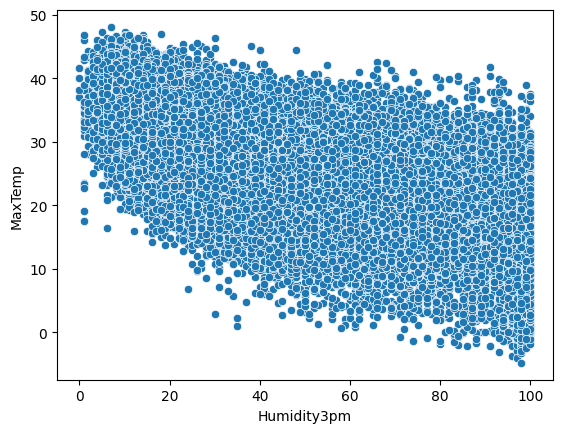

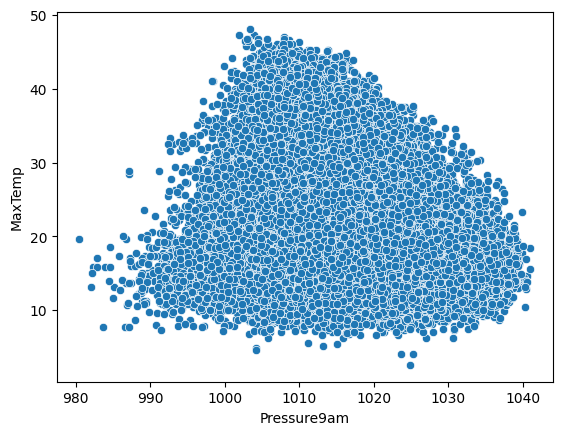

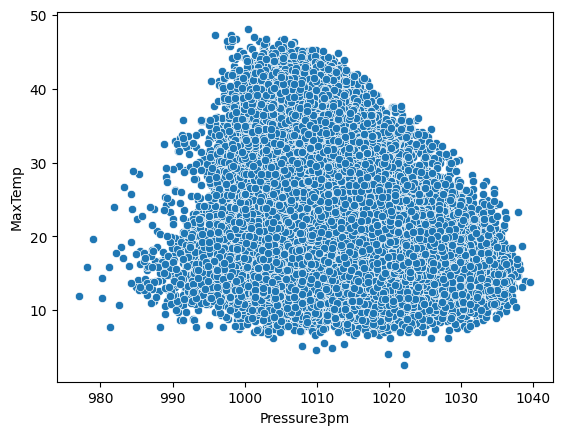

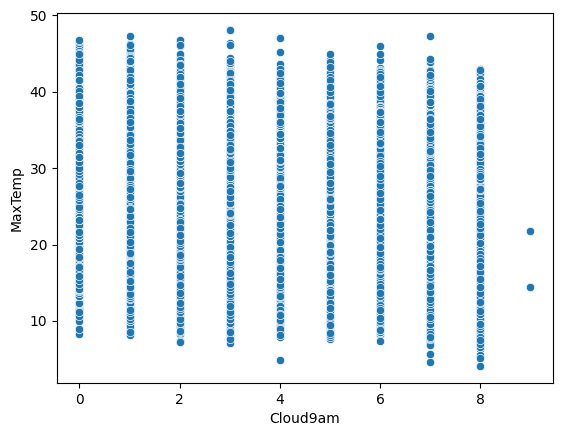

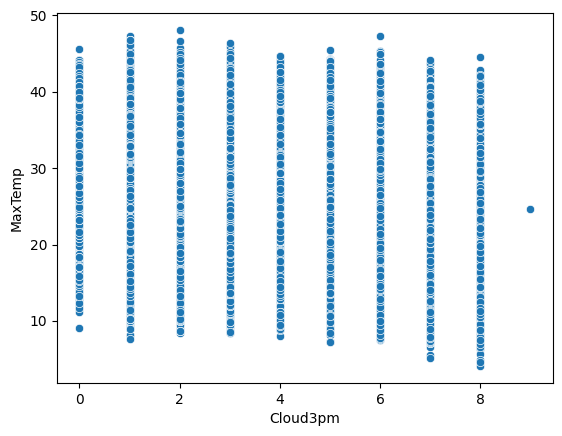

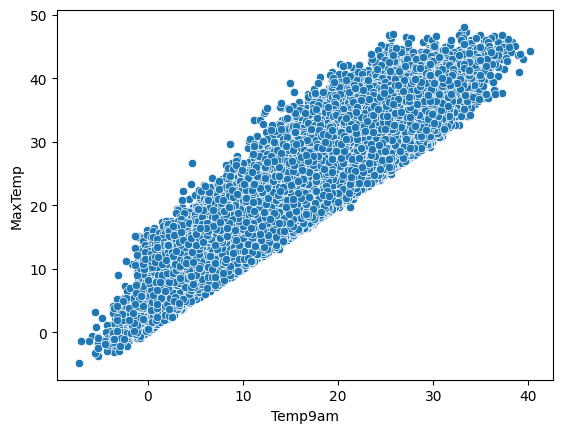

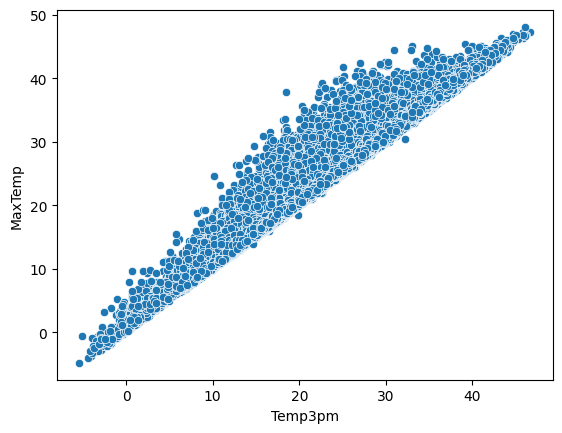

In [40]:
#scatter plot to establish relations
dt = ["MinTemp", "Rainfall", "Evaporation", "Sunshine", "WindGustSpeed",
      "WindSpeed9am", "WindSpeed3pm", "Humidity9am", "Humidity3pm",
      "Pressure9am", "Pressure3pm", "Cloud9am", "Cloud3pm", "Temp9am", "Temp3pm"]
for i in dt:
    sb.scatterplot(data=df, x=i, y="MaxTemp")
    plt.show()

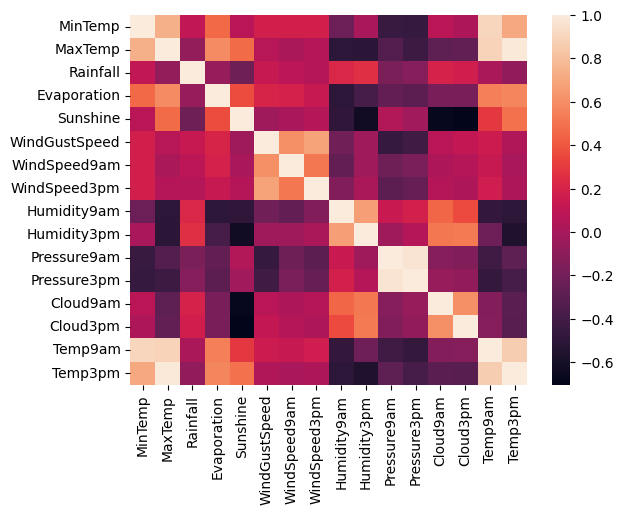

In [41]:
#Correlation making
s = df.select_dtypes(include="number").corr()
sb.heatmap(s)
plt.show()

**Missing value treatment:**

In [57]:
#Treating null values
impute = KNNImputer(n_neighbors=5)
cols = df.select_dtypes(include="number").columns
df[cols] = impute.fit_transform(df[cols])
print(df.isnull().sum())


MinTemp                0
MaxTemp                0
Rainfall               0
WindGustDir            0
WindGustSpeed          0
                      ..
Location_Wollongong    0
Location_Woomera       0
Year                   0
Month                  0
Day                    0
Length: 68, dtype: int64


**Treating outlying values:**

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustDir', 'WindGustSpeed',
       'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm',
       'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow', 'Location_Albany',
       'Location_Albury', 'Location_AliceSprings', 'Location_BadgerysCreek',
       'Location_Ballarat', 'Location_Bendigo', 'Location_Brisbane',
       'Location_Cairns', 'Location_Canberra', 'Location_Cobar',
       'Location_CoffsHarbour', 'Location_Dartmoor', 'Location_Darwin',
       'Location_GoldCoast', 'Location_Hobart', 'Location_Katherine',
       'Location_Launceston', 'Location_Melbourne',
       'Location_MelbourneAirport', 'Location_Mildura', 'Location_Moree',
       'Location_MountGambier', 'Location_MountGinini', 'Location_Newcastle',
       'Location_Nhil', 'Location_NorahHead', 'Location_NorfolkIsland',
       'Location_Nuriootpa', 'Location_PearceRAAF', 'Location_Penrith',
       'Locatio

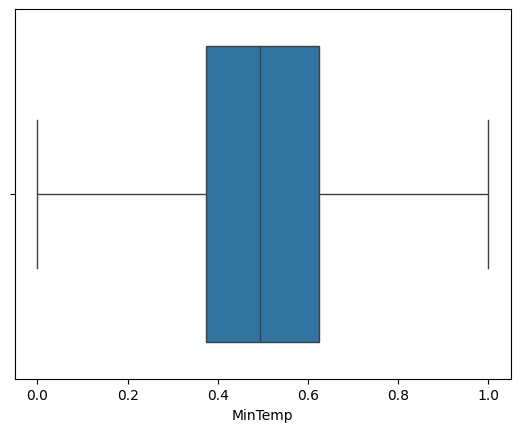

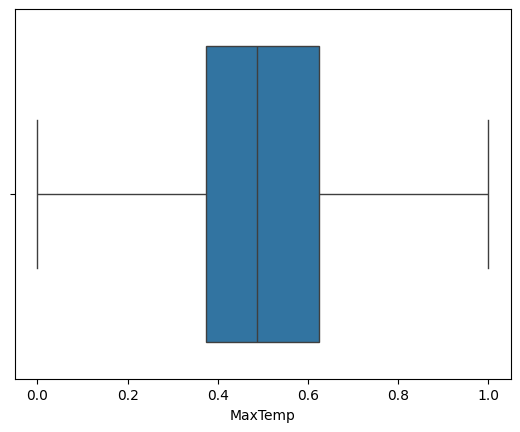

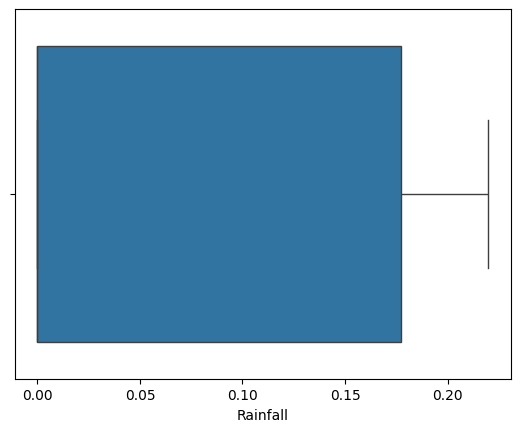

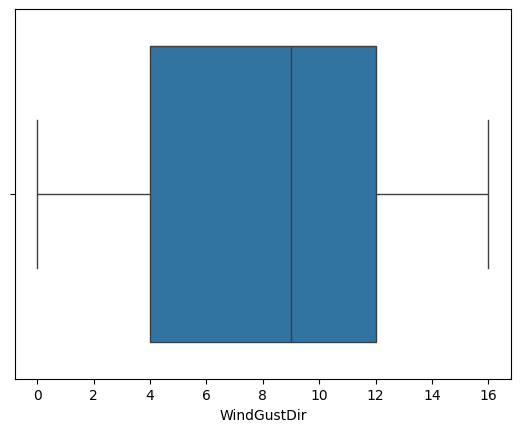

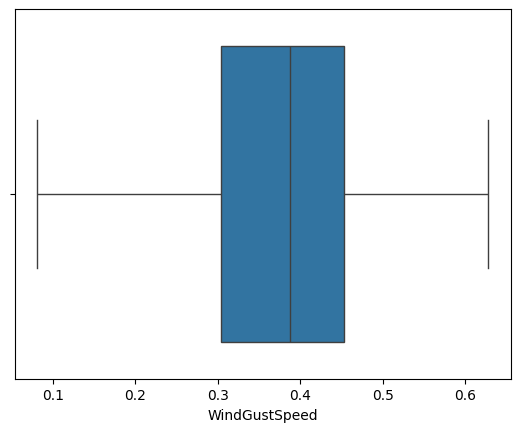

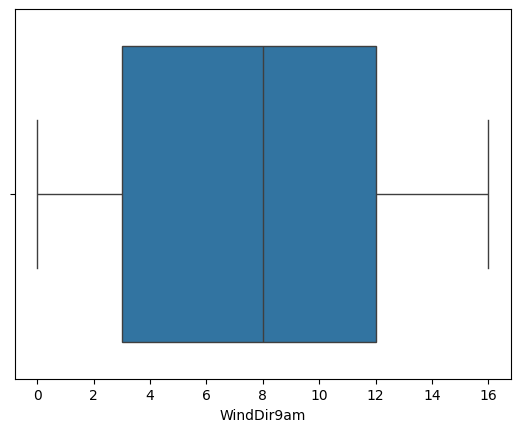

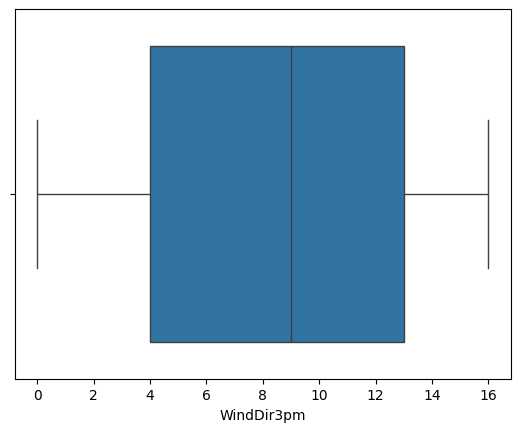

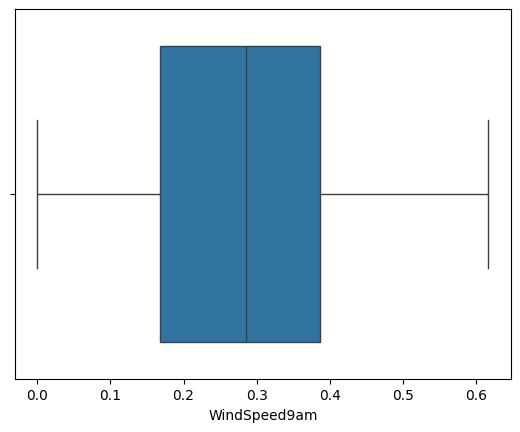

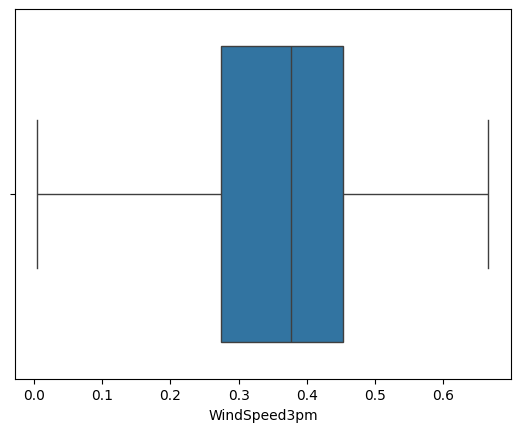

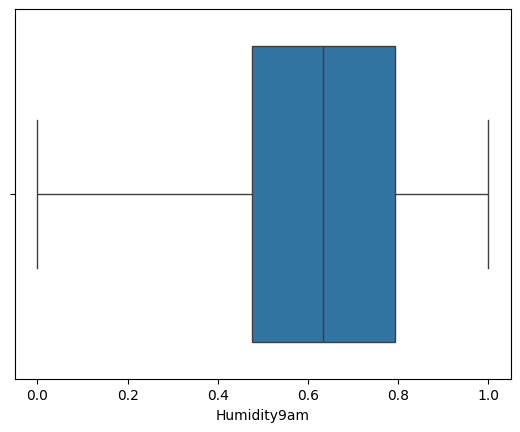

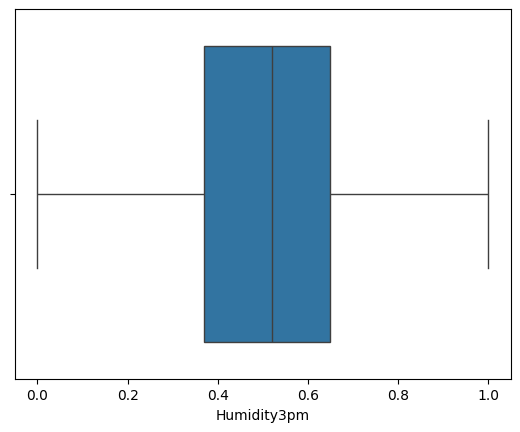

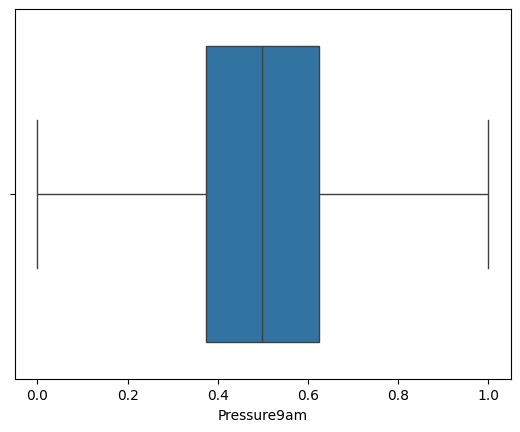

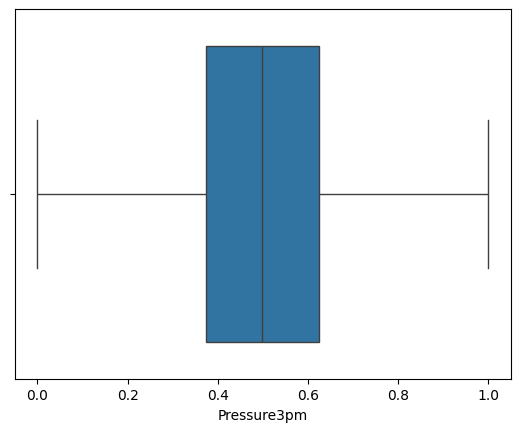

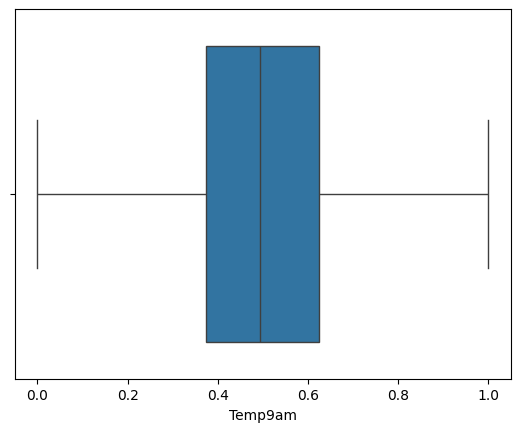

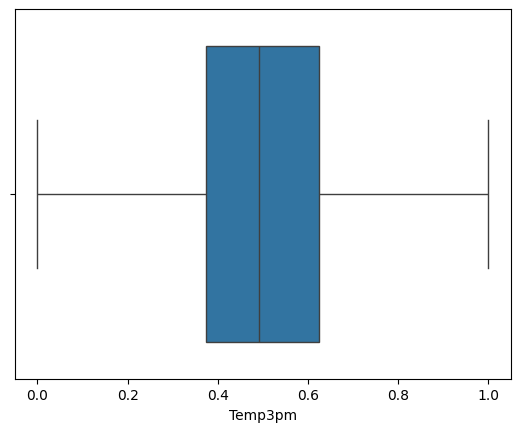

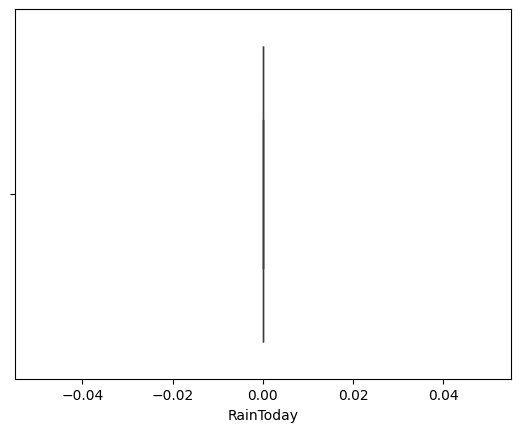

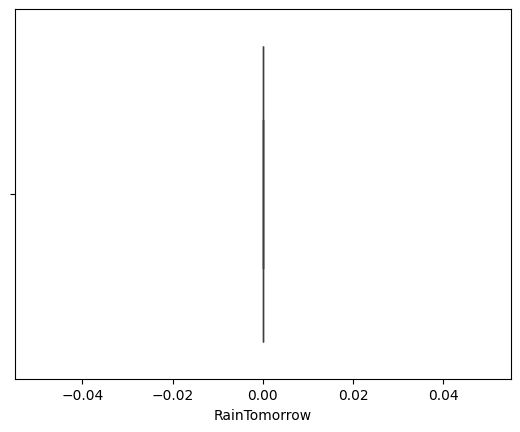

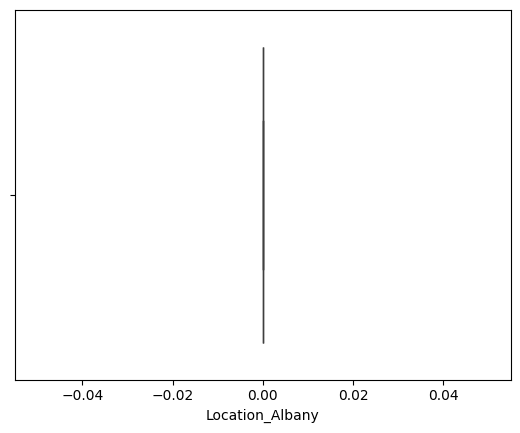

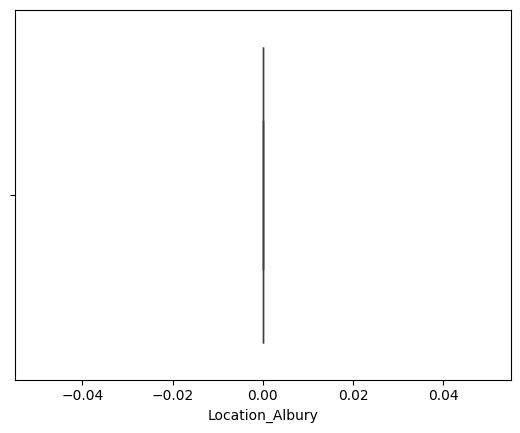

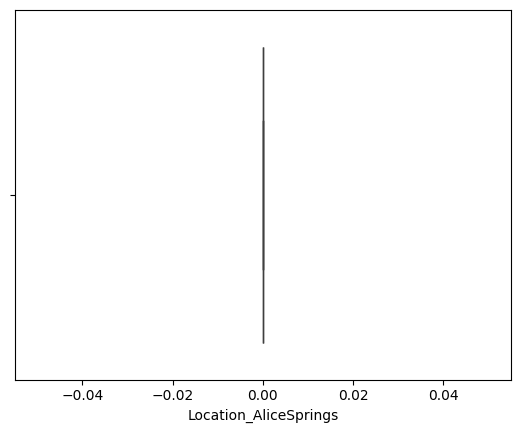

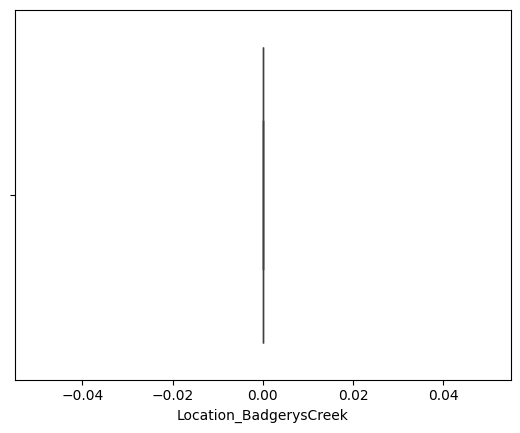

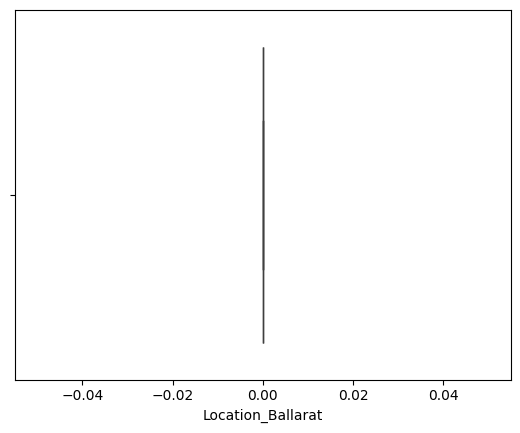

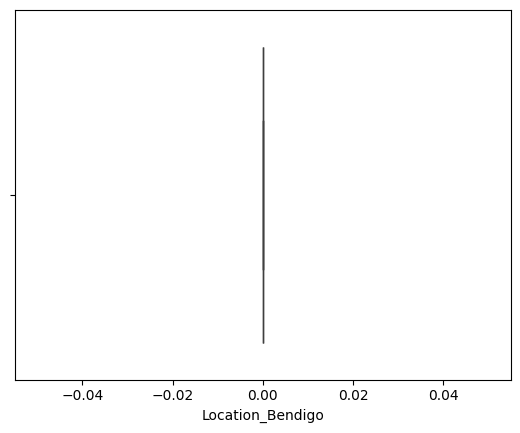

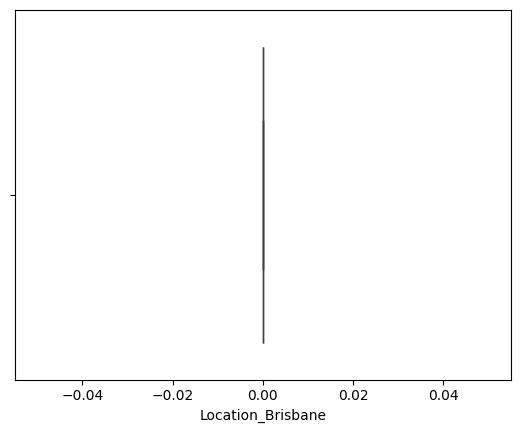

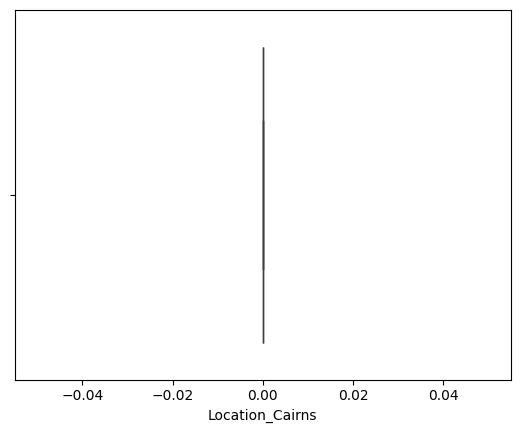

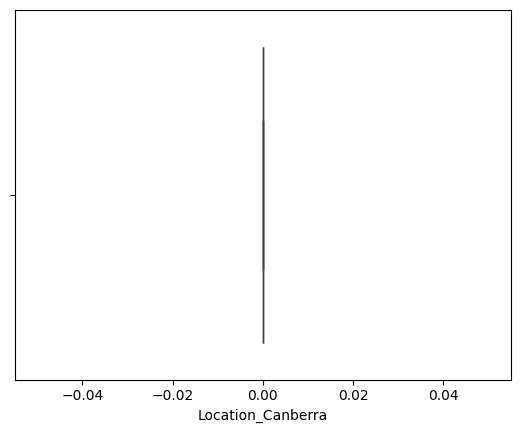

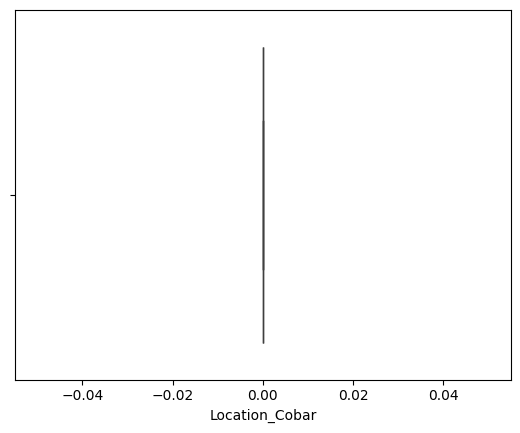

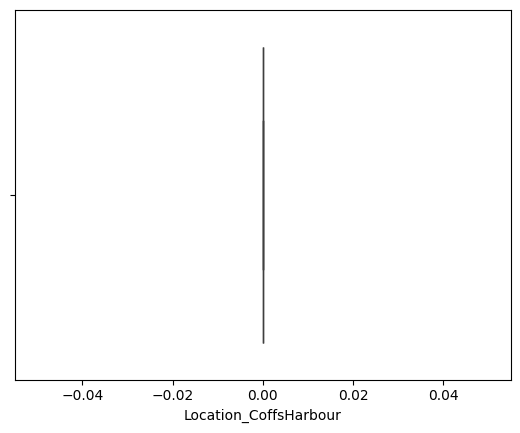

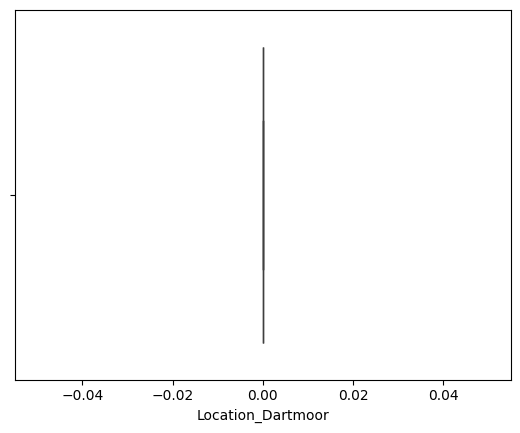

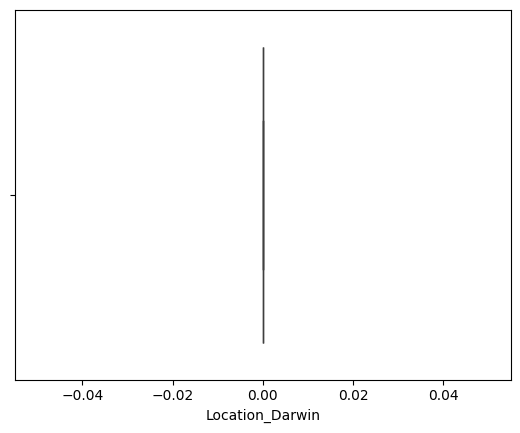

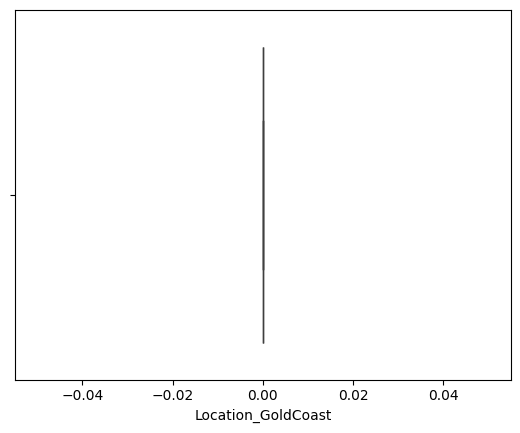

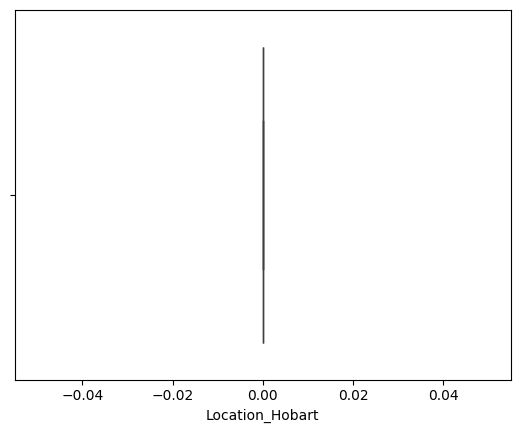

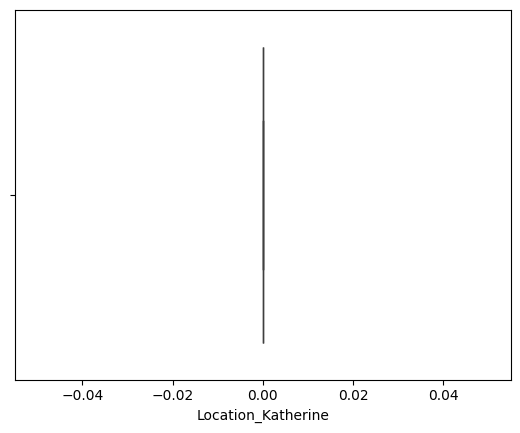

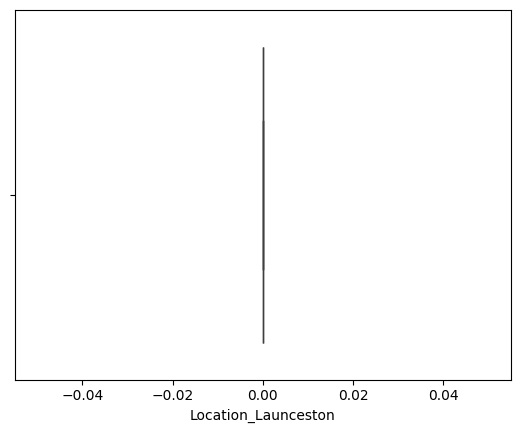

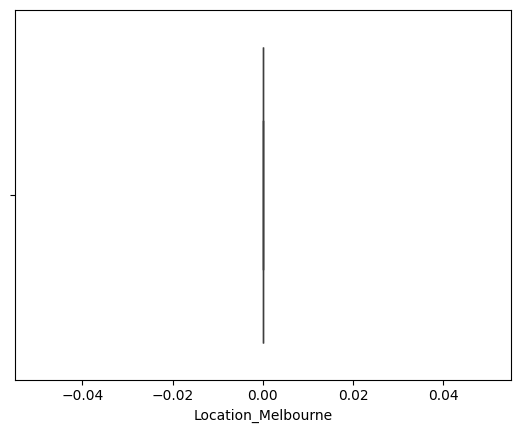

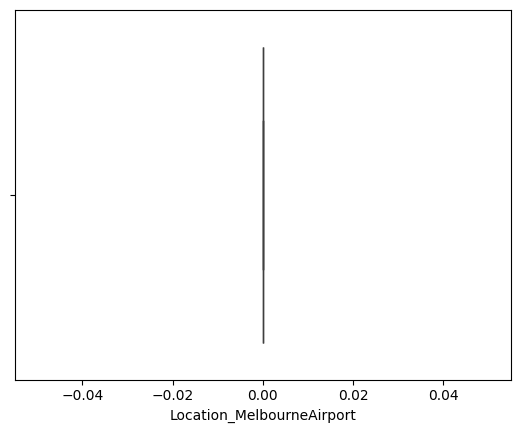

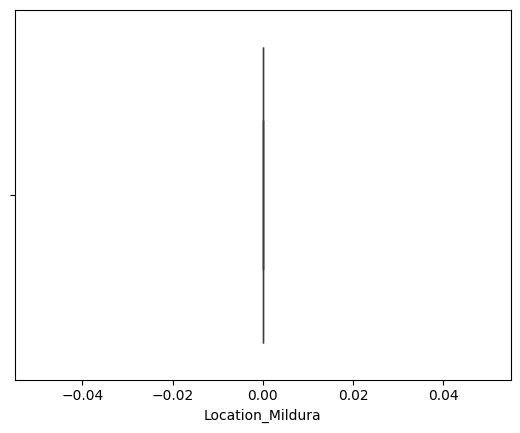

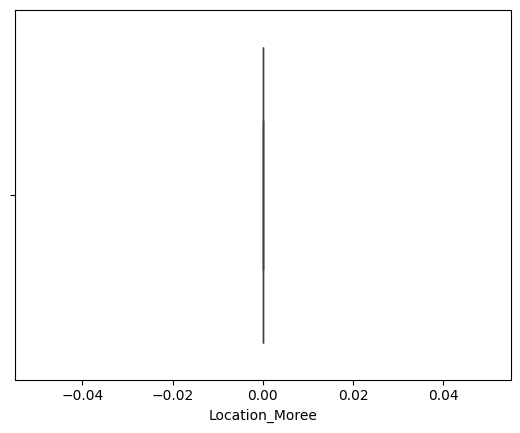

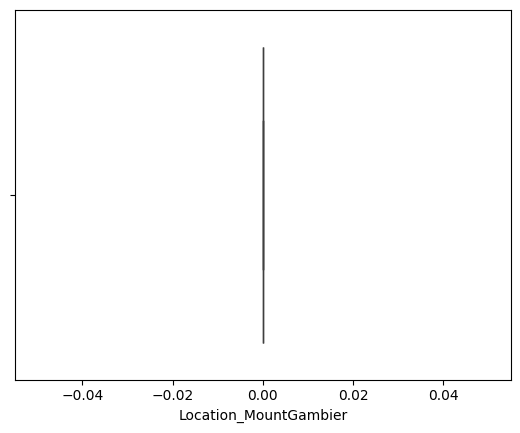

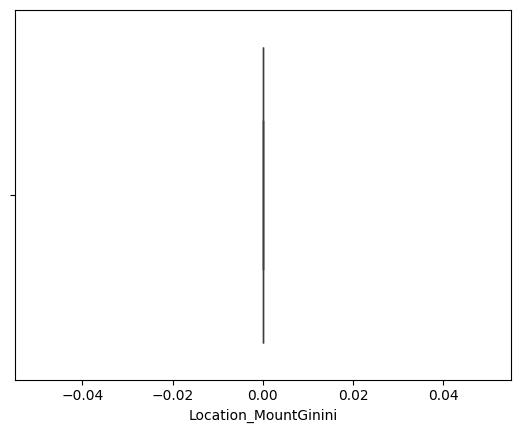

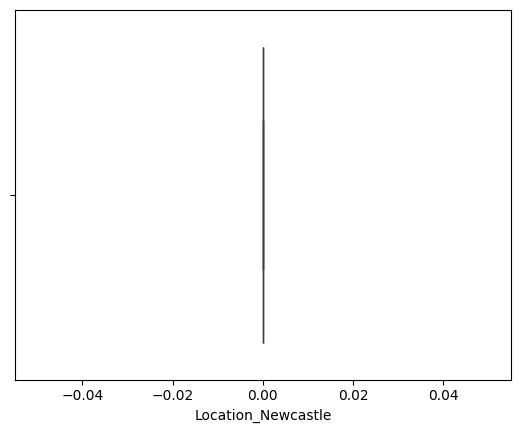

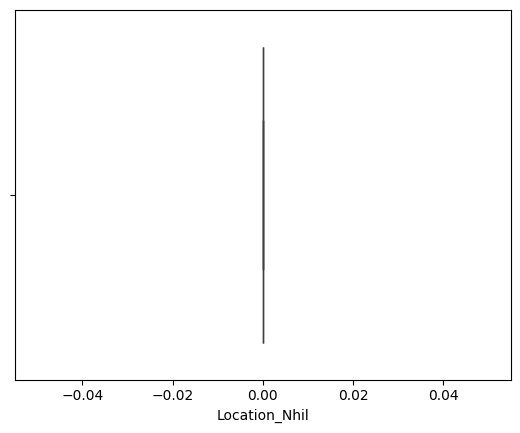

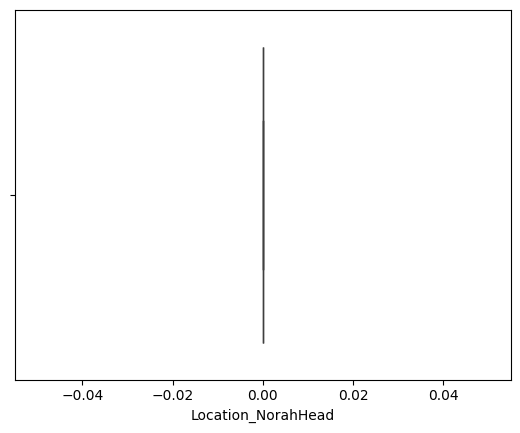

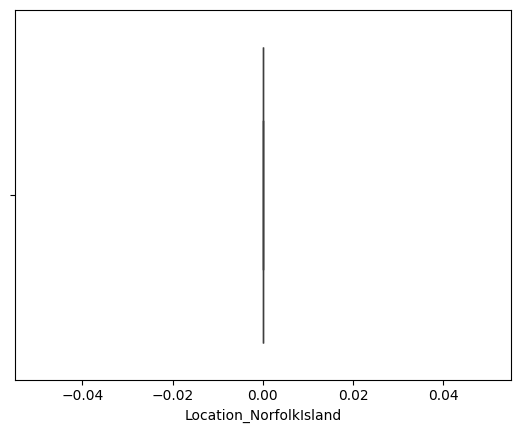

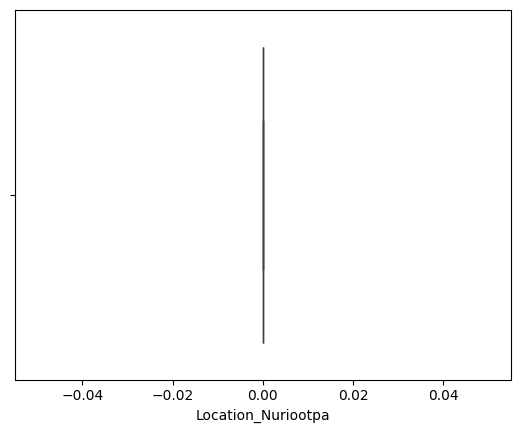

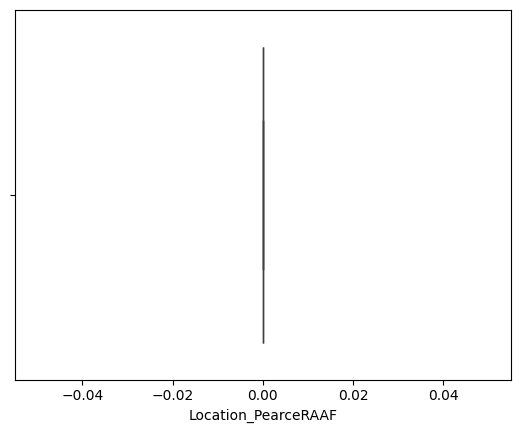

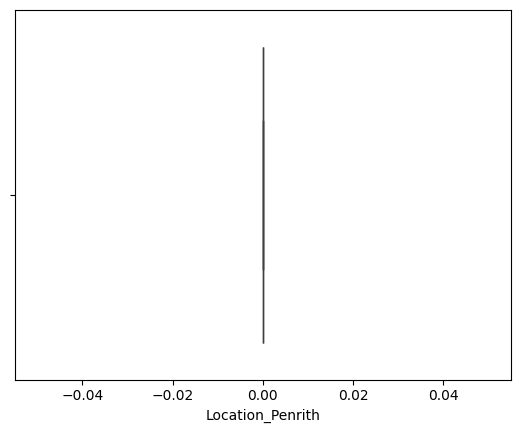

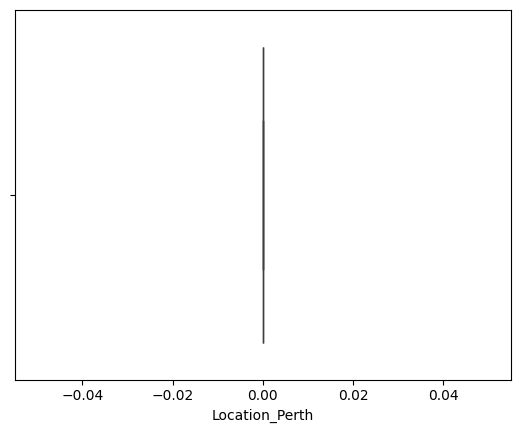

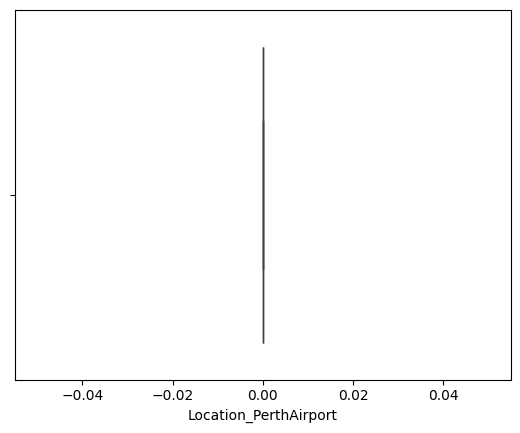

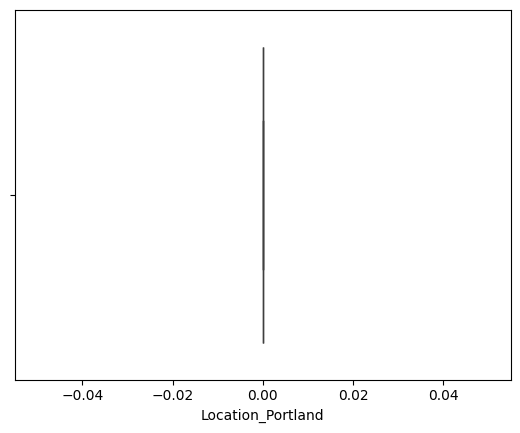

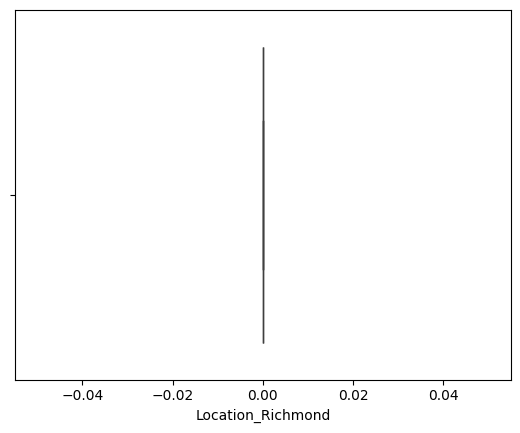

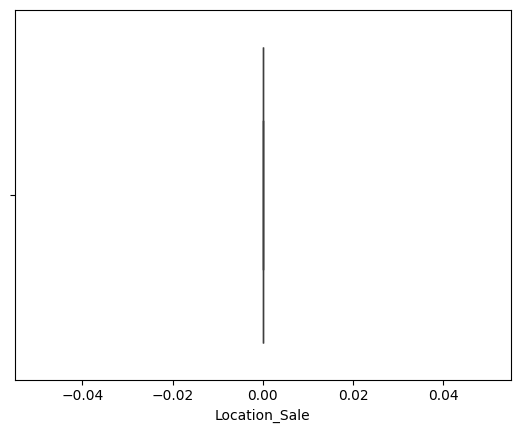

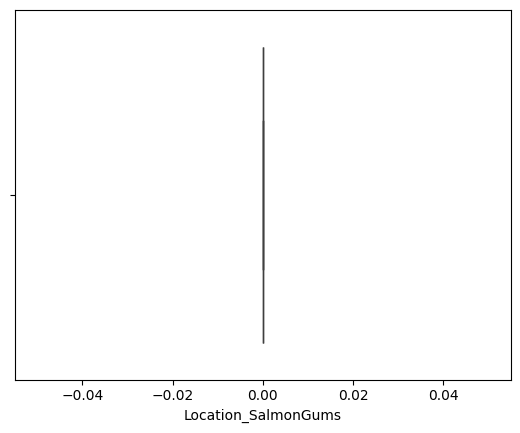

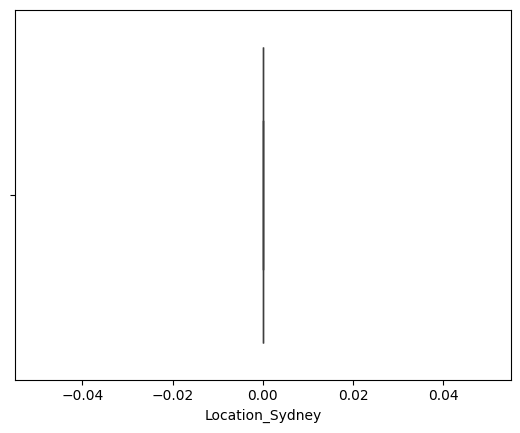

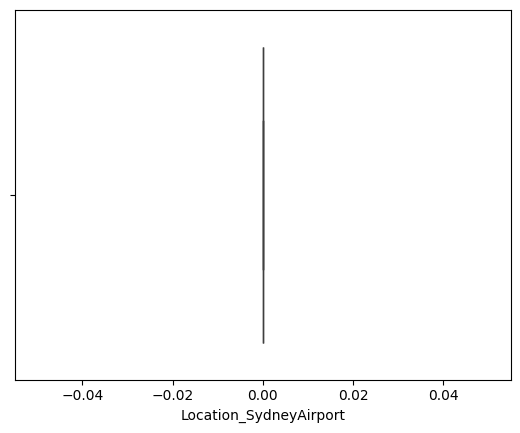

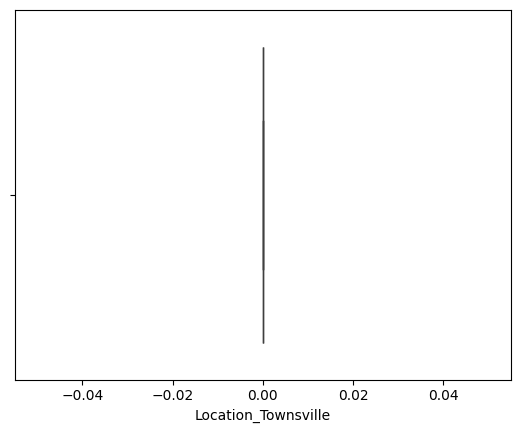

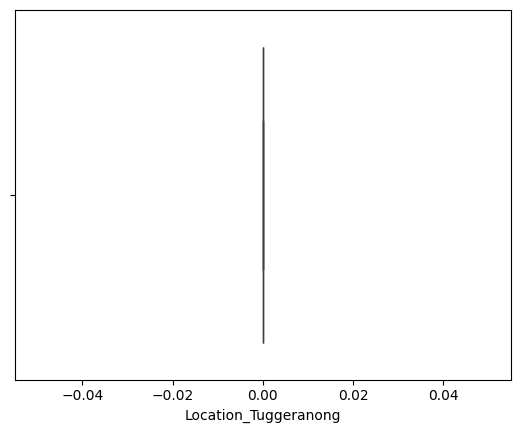

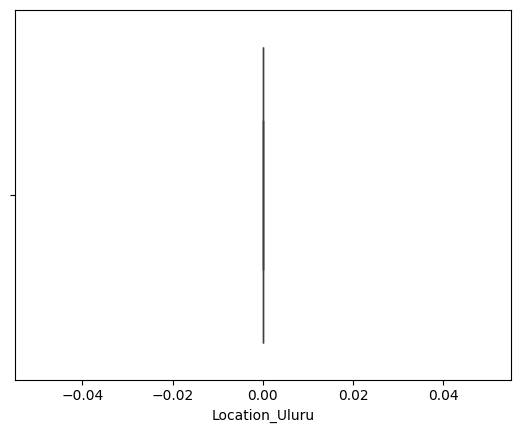

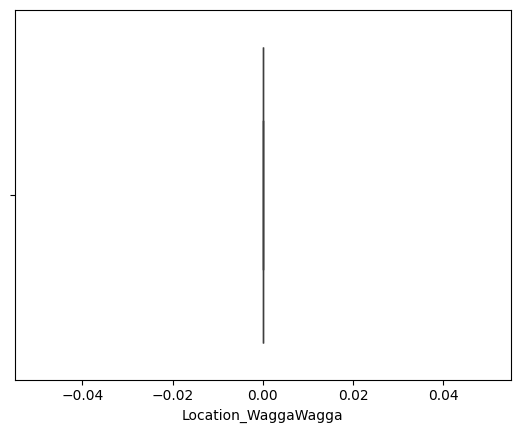

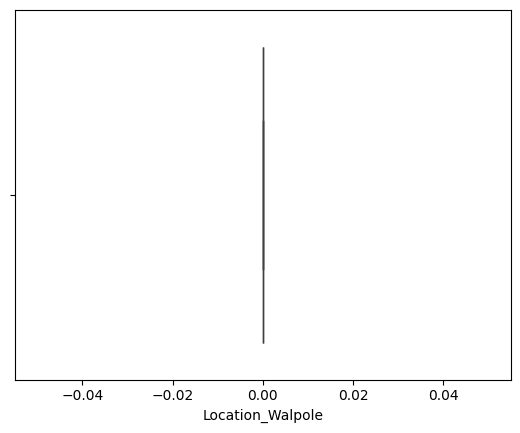

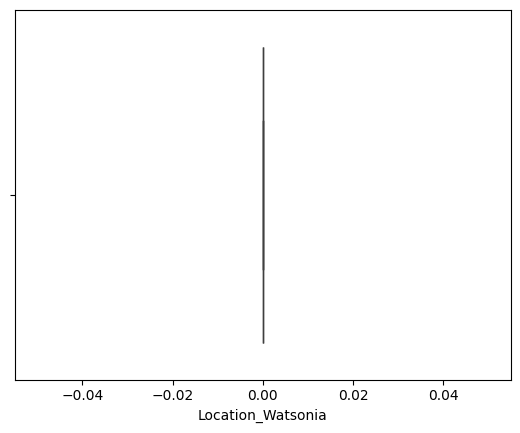

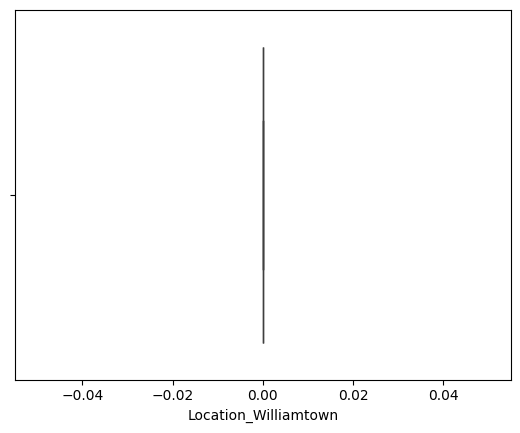

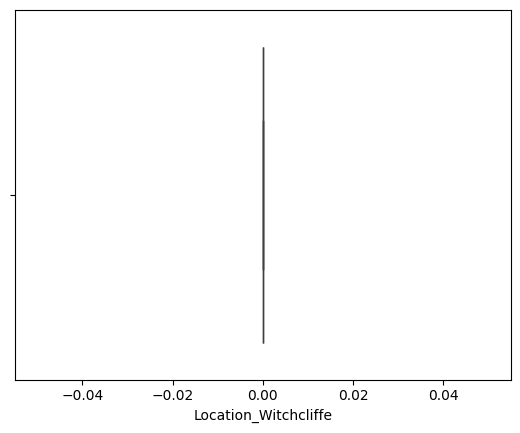

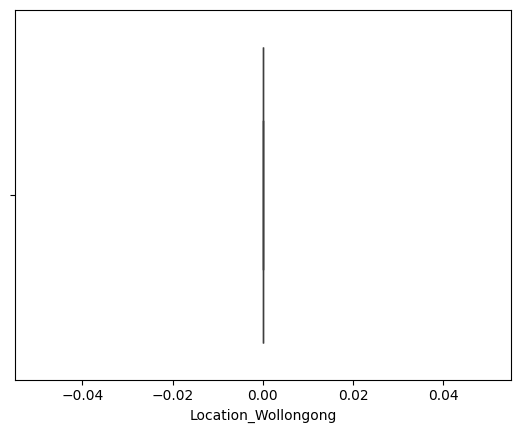

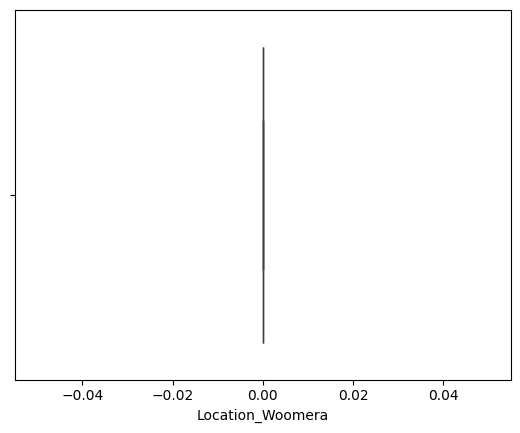

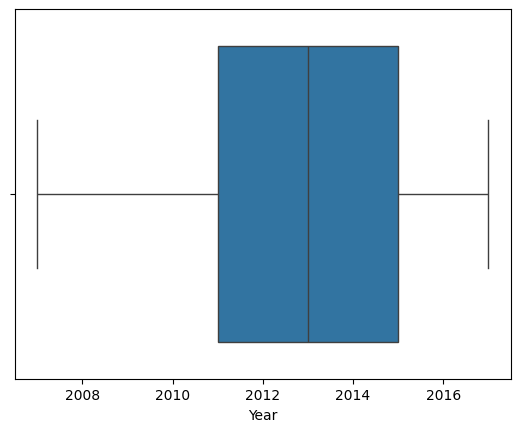

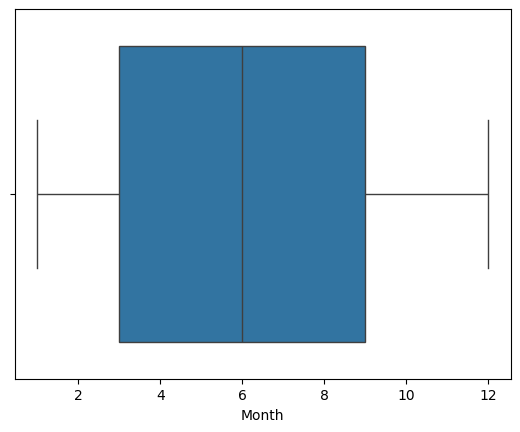

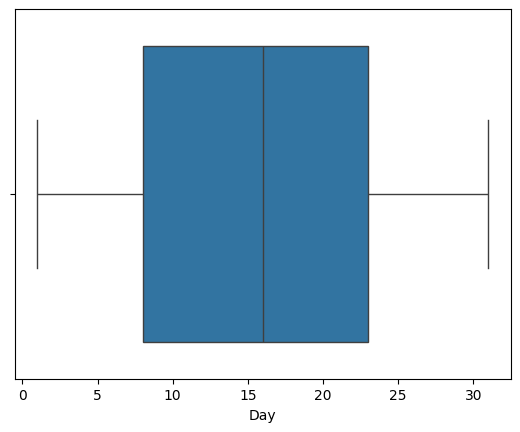

In [58]:
#treating outliers using percentiles (YOU HAVE TO TREAT NULL VALUES BEFOREHAND)
cols = df.select_dtypes(include="number").columns
print(cols)
def whisker(col):
    q1, q3 = np.percentile(col, [25, 75])
    iqr = q3 - q1
    lw = q1 - 1.5*iqr
    uw = q3 + 1.5*iqr
    return lw, uw
for i in cols:
    lw, uw = whisker(df[i])
    print(whisker(df[i]))
    df[i] = np.where(df[i]<lw, lw, df[i])
    df[i] = np.where(df[i]>uw, uw, df[i])
for i in cols:
    sb.boxplot(data=df, x=i)
    plt.show()


In [59]:
# Removing duplicates
#to remove duplicates
df.drop_duplicates()


# Normalization of data and Encoding
print(pd.get_dummies(data=df, columns=["RainToday", "RainTomorrow"], drop_first=True))

         MinTemp   MaxTemp  Rainfall  WindGustDir  WindGustSpeed  WindDir9am  \
0       0.531593  0.495098  0.177364         14.0       0.434774        14.0   
1       0.366758  0.549020  0.000000         15.0       0.434774         7.0   
2       0.517857  0.563725  0.000000         16.0       0.452828        14.0   
3       0.416209  0.620098  0.000000          5.0       0.222287        10.0   
4       0.644231  0.725490  0.205988         14.0       0.406758         1.0   
...          ...       ...       ...          ...            ...         ...   
145455  0.240385  0.507353  0.000000          0.0       0.304169        10.0   
145456  0.262363  0.553922  0.000000          7.0       0.197075        10.0   
145457  0.311813  0.593137  0.000000          3.0       0.367523        10.0   
145458  0.377747  0.595588  0.000000         10.0       0.270218        11.0   
145459  0.572802  0.487745  0.000000          4.0       0.387420         2.0   

        WindDir3pm  WindSpeed9am  WindS

In [60]:
df.head()

,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,...,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera,Year,Month,Day
0,0.531593,0.495098,0.177364,14.0,0.434774,14.0,15.0,0.401701,0.452911,0.646341,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2008.0,12.0,1.0
1,0.366758,0.549020,0.000000,15.0,0.434774,7.0,16.0,0.100872,0.423028,0.317073,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2008.0,12.0,2.0
2,0.517857,0.563725,0.000000,16.0,0.452828,14.0,16.0,0.386388,0.481777,0.243902,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2008.0,12.0,3.0
3,0.416209,0.620098,0.000000,5.0,0.222287,10.0,0.0,0.249028,0.198331,0.329268,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2008.0,12.0,4.0
4,0.644231,0.725490,0.205988,14.0,0.406758,1.0,8.0,0.168235,0.392057,0.780488,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2008.0,12.0,5.0


In [61]:
df.to_csv('cleaned_data.csv', index=False)